# Assignment 1: Linear Regression using Matrix Method

## Objective
To implement Linear Regression using the Ordinary Least Squares (OLS) matrix formulation to predict house prices.

### Libraries Used
- NumPy
- Pandas
- Matplotlib
- Seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('data.csv')

df.head()

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,1,143.635030,1.0,3.0,3.0,1967.0,1.0,1.0,48.0,8.297631,5.935734,6021
1,2,287.678577,1.0,2.0,1.0,1949.0,0.0,1.0,37.0,6.061466,10.827392,5914
2,3,232.998485,1.0,3.0,2.0,1923.0,1.0,0.0,14.0,2.911442,6.904599,4645
3,4,199.664621,5.0,2.0,2.0,1918.0,0.0,0.0,17.0,2.070949,8.284019,5831
4,5,89.004660,4.0,3.0,3.0,1999.0,1.0,0.0,34.0,1.523278,14.648277,6199


In [4]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape of Dataset:
(500, 12)

Column Names:
Index(['ID', 'Square_Feet', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors',
       'Year_Built', 'Has_Garden', 'Has_Pool', 'Garage_Size', 'Location_Score',
       'Distance_to_Center', 'Price'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  500 non-null    int64  
 1   Square_Feet         495 non-null    float64
 2   Num_Bedrooms        494 non-null    float64
 3   Num_Bathrooms       499 non-null    float64
 4   Num_Floors          497 non-null    float64
 5   Year_Built          498 non-null    float64
 6   Has_Garden          494 non-null    float64
 7   Has_Pool            499 non-null    float64
 8   Garage_Size         496 non-null    float64
 9   Location_Score      499 non-null    float64
 10  Distance_to_Center  4

In [5]:
df.describe()

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
count,500.000000,495.000000,494.000000,499.000000,497.000000,498.000000,494.000000,499.000000,496.000000,499.000000,499.000000,500.000000
mean,250.500000,174.568172,2.955466,1.977956,1.963783,1957.734940,0.536437,0.490982,30.225806,5.156770,10.482469,5822.106000
std,144.481833,74.952343,1.441925,0.819880,0.802401,35.470026,0.499176,0.500420,11.536040,2.851229,5.586431,1222.726482
min,1.000000,51.265396,1.000000,1.000000,1.000000,1900.000000,0.000000,0.000000,10.000000,0.004428,0.062818,2769.000000
25%,125.750000,109.649929,2.000000,1.000000,1.000000,1926.250000,0.000000,0.000000,20.000000,2.758926,6.076542,5031.000000
50%,250.500000,178.023265,3.000000,2.000000,2.000000,1959.000000,1.000000,0.000000,30.000000,5.197043,10.911704,5747.500000
75%,375.250000,239.828895,4.000000,3.000000,3.000000,1988.000000,1.000000,1.000000,41.000000,7.726950,15.073287,6659.500000
max,500.000000,298.241199,5.000000,3.000000,3.000000,2022.000000,1.000000,1.000000,49.000000,9.995439,19.927966,9607.000000


In [6]:
print(df.isnull().sum())

ID                    0
Square_Feet           5
Num_Bedrooms          6
Num_Bathrooms         1
Num_Floors            3
Year_Built            2
Has_Garden            6
Has_Pool              1
Garage_Size           4
Location_Score        1
Distance_to_Center    1
Price                 0
dtype: int64


Missing values were observed in several predictor variables. Since the number of missing observations was very small relative to the dataset size, mean imputation was used to replace missing values while retaining all observations for model estimation.

In [7]:
df = df.fillna(df.mean(numeric_only=True))

print(df.isnull().sum())

ID                    0
Square_Feet           0
Num_Bedrooms          0
Num_Bathrooms         0
Num_Floors            0
Year_Built            0
Has_Garden            0
Has_Pool              0
Garage_Size           0
Location_Score        0
Distance_to_Center    0
Price                 0
dtype: int64


## Exploratory Data Analysis
The following visualizations help understand the distribution of variables and relationships with the target variable.

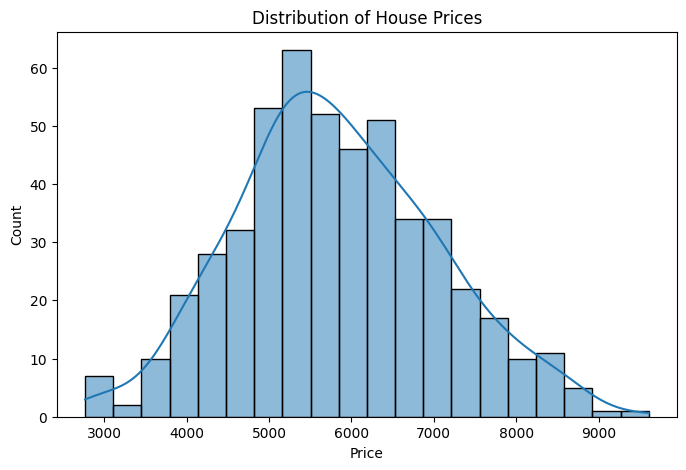

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], bins=20, kde=True)
plt.title("Distribution of House Prices")
plt.show()

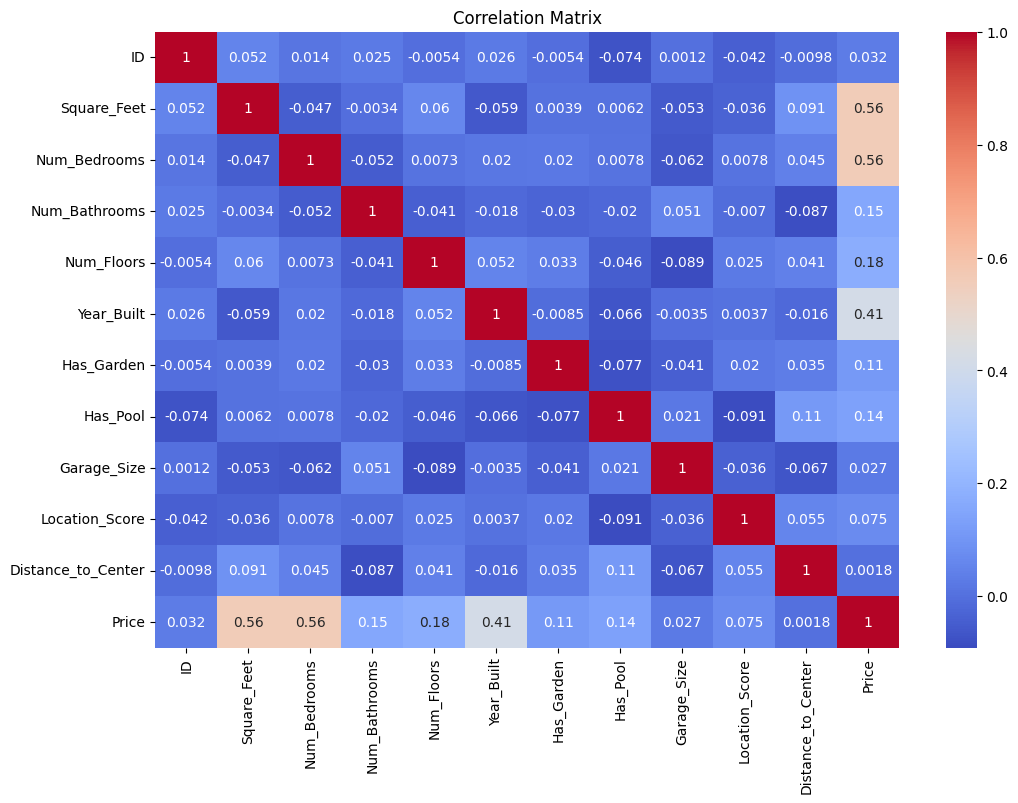

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

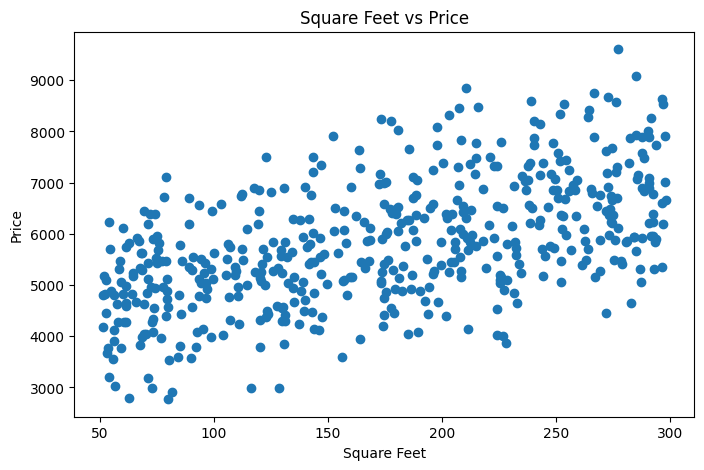

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df["Square_Feet"], df["Price"])
plt.xlabel("Square Feet")
plt.ylabel("Price")
plt.title("Square Feet vs Price")
plt.show()

In [11]:
X = df.drop(["ID", "Price"], axis=1)

y = df["Price"].values.reshape(-1,1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500, 10)
y shape: (500, 1)


Observations:

Square_Feet -> Price = 0.56 (strong positive relationship)
Num_Bedrooms -> Price = 0.56 (strong positive relationship)
Year_Built -> Price = 0.41 (moderate positive relationship)
Num_Floors -> Price = 0.18 (weak positive relationship)

This means larger houses, more bedrooms, and newer houses tend to have higher prices.

## Linear Regression using Matrix Method

The Ordinary Least Squares (OLS) estimator is used to estimate the regression coefficients.

β = (XᵀX)⁻¹Xᵀy

In [12]:
X = X.values

# Add intercept column
X = np.column_stack((np.ones(X.shape[0]), X))

print(X.shape)

(500, 11)


Beta Coefficients

In [13]:
beta = np.linalg.inv(X.T @ X) @ X.T @ y

print("Regression Coefficients:")
print(beta)

Regression Coefficients:
[[-2.93253871e+04]
 [ 1.01705900e+01]
 [ 5.07616258e+02]
 [ 2.93648594e+02]
 [ 2.06554769e+02]
 [ 1.53875277e+01]
 [ 3.00681963e+02]
 [ 4.76879350e+02]
 [ 1.05404874e+01]
 [ 4.81557589e+01]
 [-1.92438341e+01]]


In [14]:
y_pred = X @ beta

print(y_pred[:5])

[[5979.81635593]
 [5842.64473902]
 [4891.81282353]
 [5876.58614311]
 [6321.10988124]]


RSS

In [15]:
RSS = np.sum((y - y_pred)**2)

print("RSS =", RSS)

RSS = 23888683.963824067


MSE

In [16]:
MSE = np.mean((y - y_pred)**2)

print("MSE =", MSE)

MSE = 47777.367927648134


Actual vs Predicted Plot

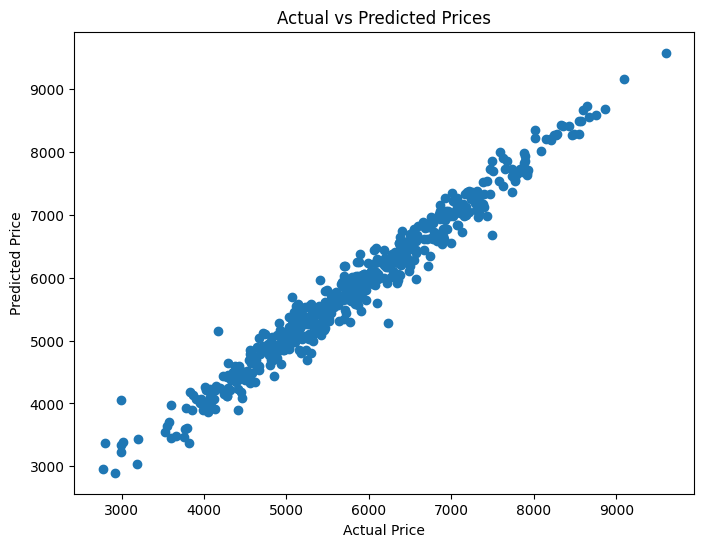

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(y, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

Observations
The Actual vs Predicted plot demonstrates a strong agreement between predicted and actual house prices. Most observations lie close to a straight-line relationship, indicating that the linear regression model captures the underlying relationship effectively.

Residual Plot

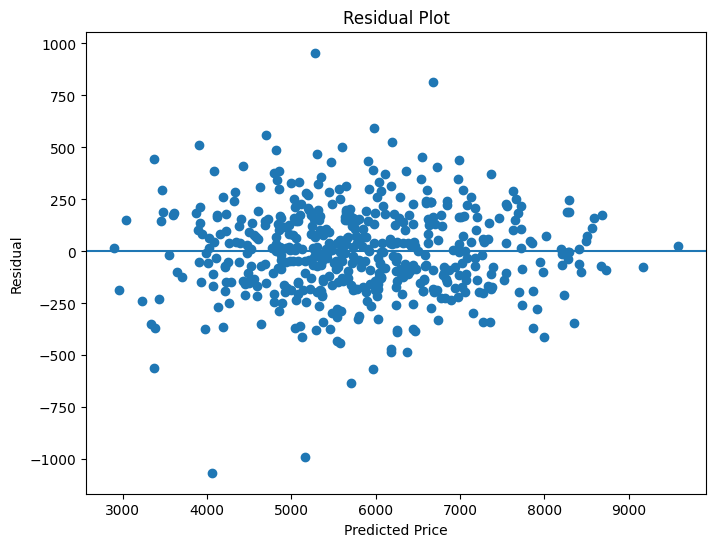

In [18]:
residuals = y - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

The residuals are randomly scattered around zero without a clear systematic pattern. This suggests that the linearity assumption is reasonable and that the model errors are approximately unbiased.

In [19]:
TSS = np.sum((y - np.mean(y))**2)

R2 = 1 - (RSS/TSS)

print("R² =", R2)

R² = 0.9679791362706545


## Conclusion

A Linear Regression model was implemented using the matrix-based Ordinary Least Squares (OLS) method.

Missing values were handled using mean imputation to preserve all observations. Exploratory Data Analysis showed that variables such as Square_Feet, Num_Bedrooms, and Year_Built have positive relationships with house prices.

Model Performance:

- RSS = 23,888,683.96
- MSE = 47,777.37
- R² = 0.968

The Actual vs Predicted plot indicates a strong agreement between predicted and actual house prices. The residual plot shows errors randomly distributed around zero without any clear pattern, suggesting that the assumptions of linear regression are reasonably satisfied.

An R² value of 0.968 indicates that approximately 96.8% of the variability in house prices is explained by the model. Therefore, the linear regression model provides highly accurate predictions for the given dataset.

## Bonus Task 1: Standardization

Standardization transforms features so that they have a mean of 0 and a standard deviation of 1.

Formula:

z = (x - μ)/σ

In [20]:
X_original = df.drop(["ID", "Price"], axis=1)

X_std = (X_original - X_original.mean()) / X_original.std()

X_std.head()

,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center
0,-0.414787,-1.364376,1.247828,1.295296,0.261733,0.934290,1.018202,1.546966,1.102687,-0.814706
1,1.516716,-1.364376,0.026914,-1.204751,-0.246758,-1.081165,1.018202,0.589588,0.317619,0.061805
2,0.783501,-1.364376,1.247828,0.045272,-0.981244,0.934290,-0.982124,-1.412203,-0.788285,-0.641100
3,0.336522,1.426522,0.026914,0.045272,-1.122492,-1.081165,-0.982124,-1.151100,-1.083364,-0.393929
4,-1.147335,0.728797,1.247828,1.295296,1.165717,0.934290,-0.982124,0.328485,-1.275639,0.746450


In [21]:
X_original = df.drop(["ID", "Price"], axis=1)

# Standardize
X_std = (X_original - X_original.mean()) / X_original.std()

# Convert to numpy
X_std = X_std.to_numpy()

# Add ONE intercept column
X_std = np.column_stack((np.ones(X_std.shape[0]), X_std))

print(X_std.shape)

(500, 11)


In [22]:
beta_std = np.linalg.pinv(X_std) @ y

y_pred_std = X_std @ beta_std

In [23]:
RSS_std = np.sum((y - y_pred_std)**2)

MSE_std = np.mean((y - y_pred_std)**2)

R2_std = 1 - RSS_std/TSS

print("RSS =", RSS_std)
print("MSE =", MSE_std)
print("R² =", R2_std)

RSS = 23888683.963824093
MSE = 47777.367927648185
R² = 0.9679791362706544


### Conclusion

The independent variables were standardized to have mean 0 and standard deviation 1.

After standardization, the regression model produced nearly identical RSS, MSE, and R² values compared to the original model. This confirms that standardization changes the scale of predictors but does not alter the predictive power of the linear regression model.

## Polynomial Regression

Polynomial features were created to capture possible non-linear relationships between predictors and house prices.

In [24]:
poly_df = df.copy()

poly_df["Square_Feet_sq"] = poly_df["Square_Feet"]**2

poly_df["Num_Bedrooms_sq"] = poly_df["Num_Bedrooms"]**2

In [25]:
X_poly = poly_df.drop(["ID", "Price"], axis=1)

X_poly = X_poly.to_numpy()

X_poly = np.column_stack((np.ones(X_poly.shape[0]), X_poly))

In [26]:
beta_poly = np.linalg.pinv(X_poly) @ y

y_pred_poly = X_poly @ beta_poly

In [27]:
RSS_poly = np.sum((y - y_pred_poly)**2)

MSE_poly = np.mean((y - y_pred_poly)**2)

R2_poly = 1 - RSS_poly/TSS

print("RSS =", RSS_poly)
print("MSE =", MSE_poly)
print("R² =", R2_poly)

RSS = 23591777.00473097
MSE = 47183.55400946194
R² = 0.9683771162218234


In [28]:
comparison = pd.DataFrame({
    "Model":["Linear","Standardized","Polynomial"],
    "RSS":[RSS, RSS_std, RSS_poly],
    "MSE":[MSE, MSE_std, MSE_poly],
    "R2":[R2, R2_std, R2_poly]
})

comparison

,Model,RSS,MSE,R2
0,Linear,2.388868e+07,47777.367928,0.967979
1,Standardized,2.388868e+07,47777.367928,0.967979
2,Polynomial,2.359178e+07,47183.554009,0.968377


The standardized model produced identical performance metrics to the original linear regression model, indicating that standardization changes the scale of the predictors but not the predictive capability of the model.

The polynomial regression model achieved a slightly higher R² and lower error metrics, suggesting that the inclusion of nonlinear terms captures additional information and marginally improves predictive performance.